# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In [1]:
import numpy as np
from scipy import signal
from scipy.io.wavfile import read
from IPython.display import Audio
import matplotlib.pyplot as plt
import librosa, librosa.display
from librosa import feature, frames_to_time, autocorrelate, clicks
from collections import Counter
plt.rcParams['figure.figsize'] = (14, 5)

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

(441000, 2)


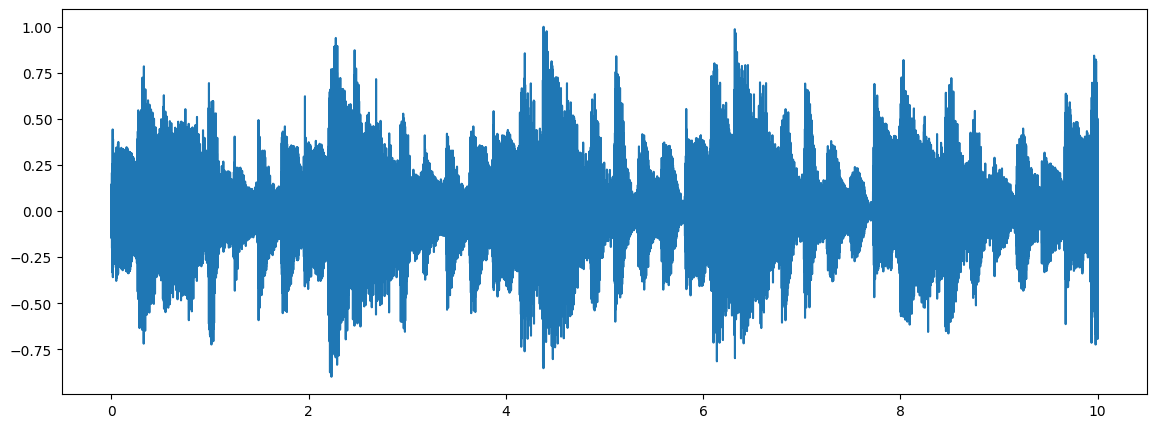

In [2]:

(fs, x) = read('../audio/80sPopDrums.wav')
(fs1, x1) = read('../audio/TheBlackKeys_track4.wav')
(fs2, x2) = read('../audio/prelude_cmaj_10s.wav')

print(x2.shape)

dur = x.size/fs
time = np.arange(0, dur, 1/fs)
xnorm = x/np.max(np.abs(x))

dur1 = x1.size/fs1
time1 = np.arange(0, dur1, 1/fs1)
xnorm1 = x1/np.max(np.abs(x1))

x2 = x2[:,0]
dur2 = x2.size/fs2
time2 = np.arange(0, dur2, 1/fs2)
xnorm2 = x2/np.max(np.abs(x2))

plt.plot(time2, xnorm2)



#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

In [3]:
hop_length = 512
frame_length = 1024

# Energy and RMSE for Audio1
energy = np.array([sum(abs(xnorm[i:i+frame_length])) for i in range(0, len(xnorm), hop_length)])

rmse = np.array([])
for i in range(0, len(xnorm), hop_length):
    rmse_i = np.sqrt(np.mean(abs(xnorm[i:i+frame_length]**2)))
    rmse = np.append(rmse, rmse_i)

frames = range(len(energy))
t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)

# Energy and RMSE for Audio1
energy1 = np.array([sum(abs(xnorm1[i:i+frame_length])) for i in range(0, len(xnorm1), hop_length)])

rmse1 = np.array([])
for i in range(0, len(xnorm1), hop_length):
    rmse_i1 = np.sqrt(np.mean(abs(xnorm1[i:i+frame_length]**2)))
    rmse1 = np.append(rmse1, rmse_i1)

frames1 = range(len(energy1))
t1 = librosa.frames_to_time(frames1, sr=fs1, hop_length=hop_length)

# Energy and RMSE for Audio1
energy2 = np.array([sum(abs(xnorm2[i:i+frame_length])) for i in range(0, len(xnorm2), hop_length)])

rmse2 = np.array([])
for i in range(0, len(xnorm2), hop_length):
    rmse_i2 = np.sqrt(np.mean(abs(xnorm2[i:i+frame_length]**2)))
    rmse2 = np.append(rmse2, rmse_i2)

frames2 = range(len(energy2))
t2 = librosa.frames_to_time(frames2, sr=fs2, hop_length=hop_length)


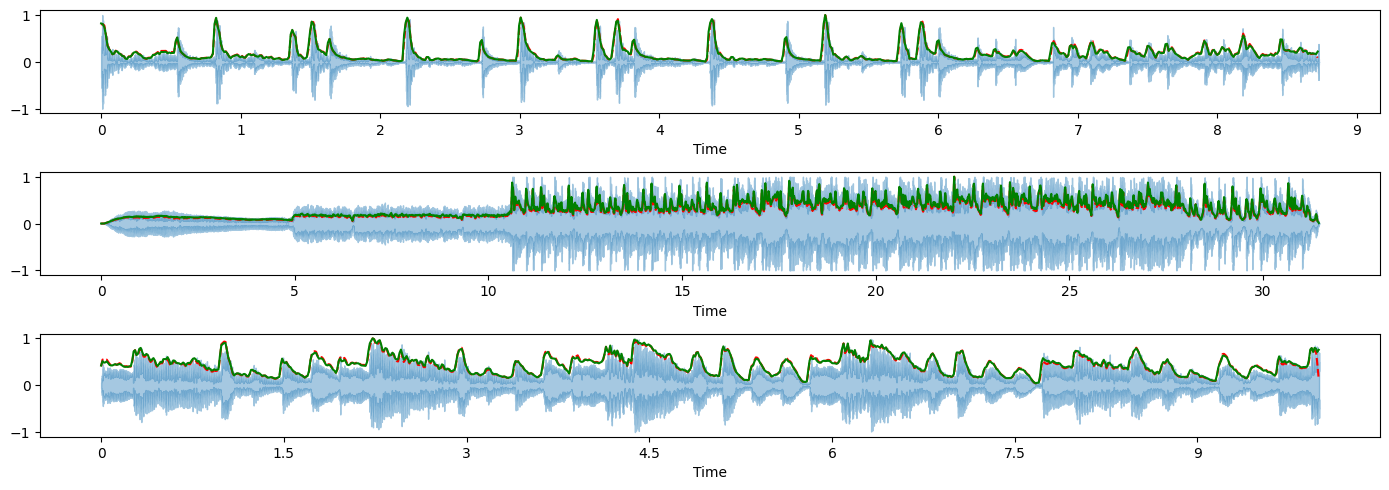

In [4]:
plt.subplot(3,1,1)
librosa.display.waveshow(xnorm, sr=fs, alpha=0.4)
plt.plot(t, energy/np.max(energy), 'r--')
plt.plot(t, rmse/np.max(rmse), color='g')

plt.subplot(3,1,2)
librosa.display.waveshow(xnorm1, sr=fs1, alpha=0.4)
plt.plot(t1, energy1/np.max(energy1), 'r--')
plt.plot(t1, rmse1/np.max(rmse1), color='g')

plt.subplot(3,1,3)
librosa.display.waveshow(xnorm2, sr=fs2, alpha=0.4)
plt.plot(t2, energy2/np.max(energy2), 'r--')
plt.plot(t2, rmse2/np.max(rmse2), color='g')

plt.tight_layout()


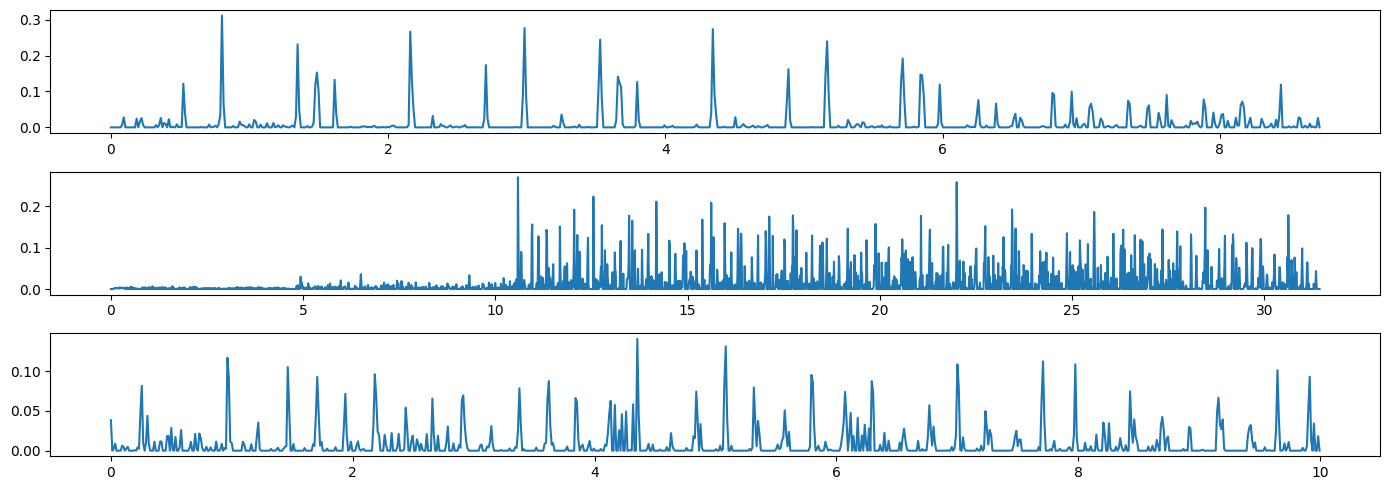

In [5]:
#Audio Signal 1 
rmse_diff = np.diff(rmse)
novelty = np.concatenate((rmse_diff, np.array([0])))
novelty[novelty < 0] = 0

rmse_diff1 = np.diff(rmse1)
novelty1 = np.concatenate((rmse_diff1, np.array([0])))
novelty1[novelty1 < 0] = 0

rmse_diff2 = np.diff(rmse2)
novelty2 = np.concatenate((rmse_diff2, np.array([0])))
novelty2[novelty2 < 0] = 0

plt.subplot(3,1,1)
plt.plot(t, novelty)
plt.subplot(3,1,2)
plt.plot(t1, novelty1)
plt.subplot(3,1,3)
plt.plot(t2, novelty2)
plt.tight_layout()



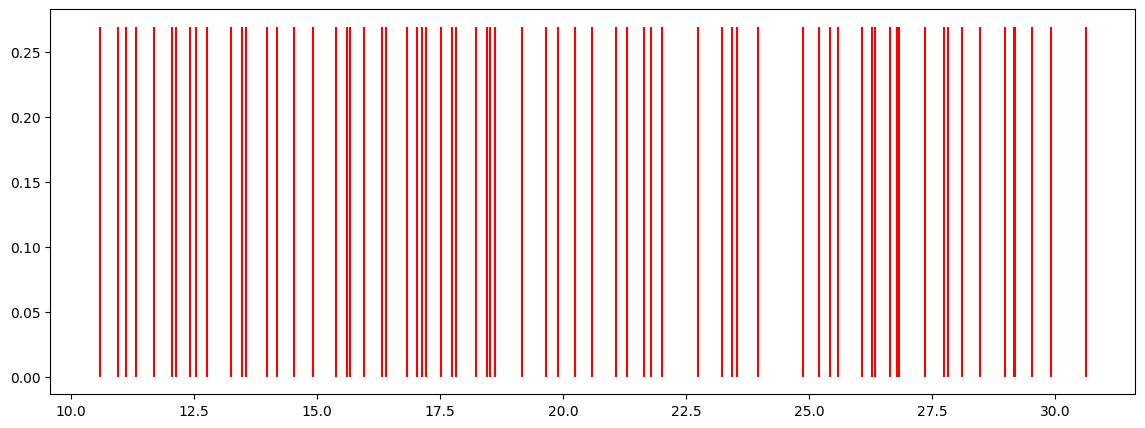

In [6]:
def peakPicking(novelty, t, threshold=0.1):
    threshold = float(threshold)
    peak_indices = []

    for i in range(1, len(novelty) - 1):
        if novelty[i] > threshold:
            if novelty[i] > novelty[i-1] and novelty[i] > novelty[i+1]:
                peak_indices.append(i)
    
    peak_indices = np.array(peak_indices)
    peak_time = t[peak_indices]

    plt.vlines(peak_time, 0, np.max(novelty), color='r')

peakPicking(novelty1, t1,threshold=0.1)


## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

ValueError: x and y must have same first dimension, but have shapes (17,) and (18,)

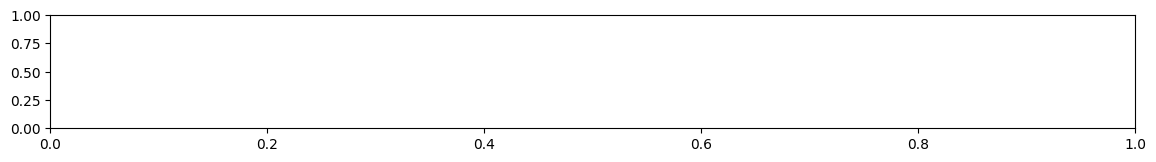

In [7]:
def globalTempo1(novelty, hop_length, fs, thresh=0.15):
    frames = range(len(novelty))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)
    peaks, properties = signal.find_peaks(novelty, height=0.1)
    peak_times = t[1:][peaks]
    iois = np.diff(peak_times)
    bpms = 60 / iois
    strength = properties['peak_heights']
    plt.plot(bpms, strength)
    plt.xlim(40, 300)

plt.subplot(3,1,1)
globalTempo1(novelty, hop_length, fs, thresh=0.3)
plt.subplot(3,1,2)
globalTempo1(novelty1, hop_length, fs1, thresh=0.3)
plt.subplot(3,1,3)
globalTempo1(novelty2, hop_length, fs2, thresh=0.3)
plt.tight_layout()

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

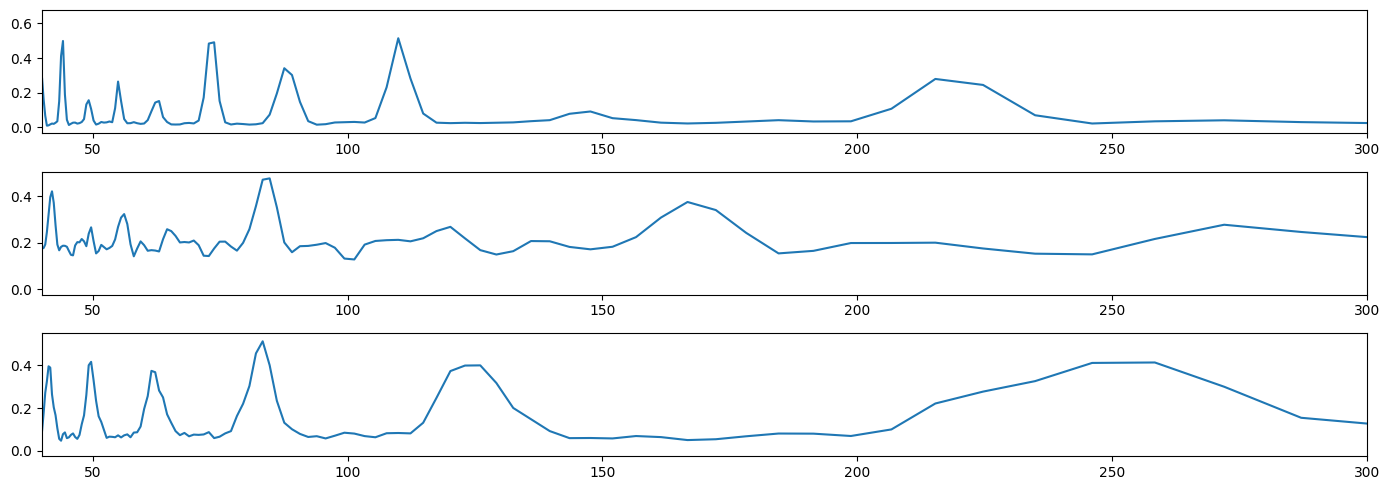

In [ ]:
def globalTempo(novelty, hop_length, fs, corr_thresh=0.3):
    ac = librosa.autocorrelate(novelty)
    ac = ac/ac.max()
    lags = np.arange(len(ac))
    lag_times = lags * hop_length / fs
    bpms = 60 / lag_times[1:]
    strength = ac[1:]
    plt.plot(bpms, strength)
    plt.xlim(40, 300)

plt.subplot(3,1,1)
globalTempo(novelty, hop_length, fs, corr_thresh=0.3)
plt.subplot(3,1,2)
globalTempo(novelty1, hop_length, fs1, corr_thresh=0.3)
plt.subplot(3,1,3)
globalTempo(novelty2, hop_length, fs2, corr_thresh=0.3)
plt.tight_layout()


Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

/var/folders/88/n40k4jj52mlcqk5ftw8mhlsm0000gn/T/ipykernel_39649/4188645203.py:1: FutureWarning: Pass y=[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.23502702e-03
 2.80223303e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.43720340e-02 0.00000000e+00 1.59504938e-02 2.56853626e-02
 6.58079988e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 6.22405324e-03 1.33822631e-04 6.69624439e-03 2.61218410e-02
 5.16457361e-04 1.21116356e-02 9.04955082e-03 0.00000000e+00
 2.27696035e-02 0.00000000e+00 1.60945006e-03 5.04625977e-04
 0.00000000e+00 8.28896838e-03 0.00000000e+00 1.83072131e-03
 6.94101429e-04 1.21363544e-01 4.04510630e-02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 8.55009004e-04 0.00000000e+00 0.00000000e

array([0.49922902])

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?